# 🏢 [Lab 1] 엔터프라이즈 비정형 문서 인덱싱 & 하이브리드 검색기 구축 실습

> **핵심 학습 목표**:
> 1. **고립된 청크의 맥락 상실(Context Loss)** 문제를 해결하는 **문맥 보존 계층 헤더(Contextual Header) & 목차(TOC) 주입** 인덱싱 파이프라인 구현
> 2. 의미 기반 벡터 검색(Dense)과 정확한 키워드/조항 번호 검색(Sparse/BM25)을 결합한 **듀얼 하이브리드 RRF(Reciprocal Rank Fusion) 검색기** 구축
> 3. 도메인 사전 기반 **쿼리 전처리(Query Preprocessing)** 및 **가상 문서 임베딩(HyDE)** 연동
> 4. 검색된 청크의 앞뒤 문맥을 온디맨드로 확장하는 **동적 윈도우 확장(Chunk Window Expansion)** 구현
> 5. **공정한 블라인드 대칭 LLM-as-a-Judge 하네스**를 통한 Naive RAG 대비 정량적 품질 검증
> 6. **한국은행 분기별 산업 보고서 PDF(총 154페이지)**의 전자 북마크 기반 **헤더 승격(Header Promotion) 정규화** 실증
> 7. **도구 설명서(Description) 강화**를 통해 시스템 프롬프트 비대화 없이 **LangGraph `create_agent` 기반 ReAct 다단계(Multi-Step) 자율 검색** 구현


## 1. 환경 설정 및 의존성 패키지 로드


In [ ]:
import os
import sys
from dotenv import load_dotenv
from IPython.display import display, Markdown

# 프로젝트 루트를 sys.path에 추가 (어디서 실행하든 rag 모듈 및 .env 정상 탐색)
PROJECT_ROOT = os.path.abspath('..') if os.path.exists('../rag') else os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

ENV_PATH = os.path.join(PROJECT_ROOT, '.env')
if os.path.exists(ENV_PATH):
    load_dotenv(ENV_PATH, override=True)
    print(f'✅ 환경변수 로드 완료: {ENV_PATH}')
else:
    load_dotenv(override=True)
    print('⚠️ .env 파일을 찾지 못해 시스템 환경변수를 사용합니다.')

## 2. 계층형 마크다운 파서 및 문맥 헤더 주입기 (`ContextualHeaderEnricher`)

문서가 청크로 잘게 쪼개지면 상위 목차(장/절/조항)와 문서 맥락이 유실되는 **'탈맥락화(Decontextualization)'** 가 발생하여 검색 오탐이 일어납니다.

이를 방지하기 위해 **LangChain의 `MarkdownHeaderTextSplitter`로 문서의 H1~H4 트리 계층을 추출**하고, **각 청크의 상단에 계층 브레드크럼(Breadcrumb)과 전체 목차(TOC)를 문맥 접두사(Context Header)로 자동 주입**하는 범용 파서를 구축합니다.


** 탈맥락화(Decontextualization) 해결책: 2가지 핵심 기법과 작동 원리**

1) Contextual Chunk Header (Pre-retrieval / Soft Constraint)
- **개념**: 청크를 분할할 때 각 청크 상단에 `[문서 제목/목차]`, `[연도/분기]`, `[산업 분류]`, `[문맥 요약]` 정보를 헤더(Header) 형태로 결합하여 임베딩합니다.
- **해결 원리**: 벡터 공간(Embedding Space) 자체에 출처 맥락(Context)이 각인되므로, "2024년 4분기 반도체" 쿼리가 입력되었을 때 헤더가 부착된 대상 청크와의 코사인 유사도가 타 소스 청크보다 월등히 높아져 오검색을 방지합니다.

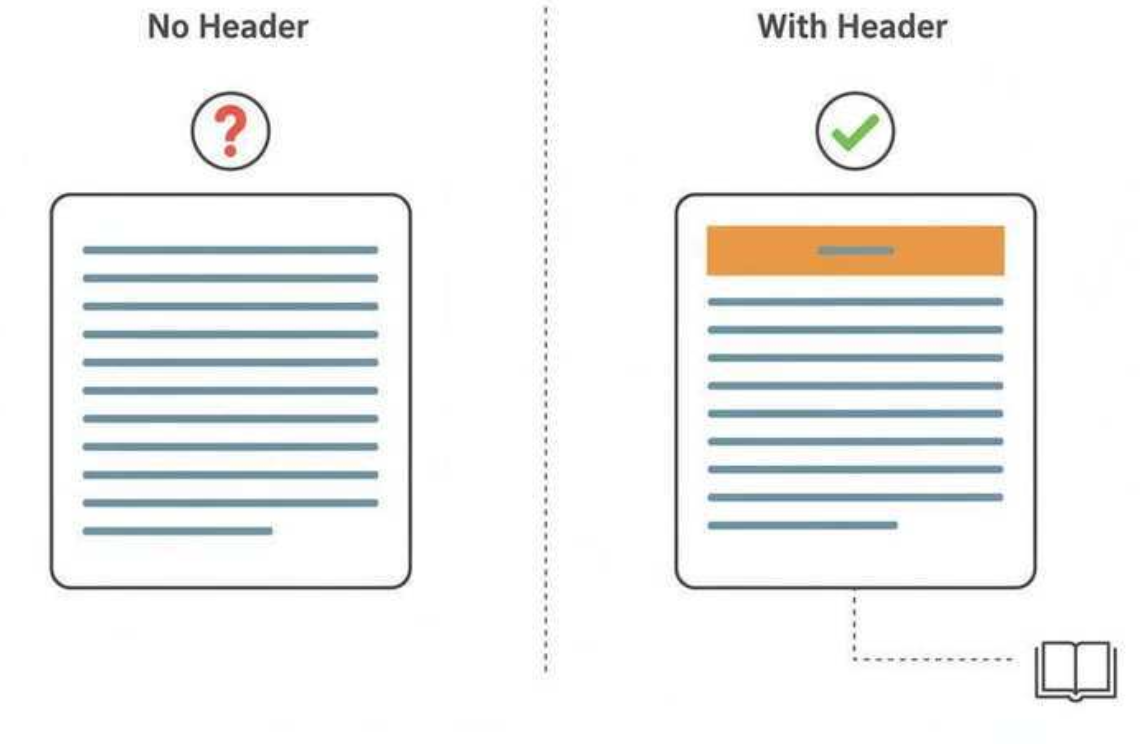

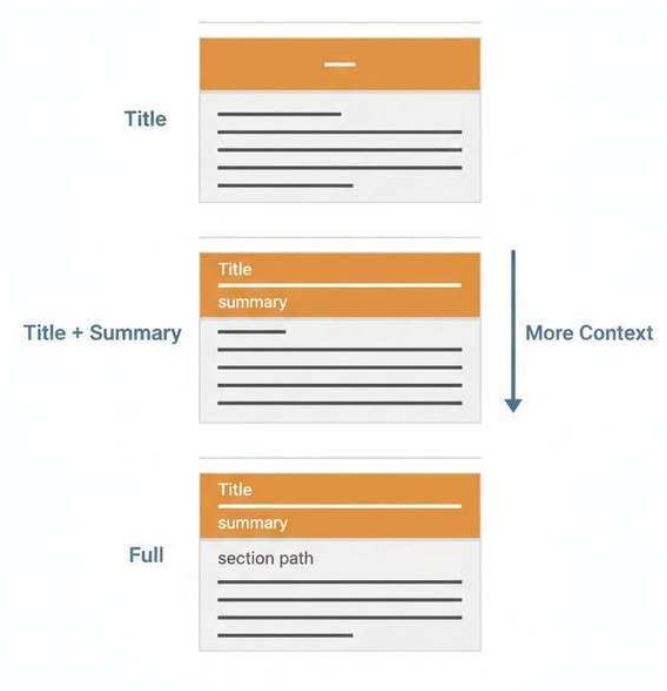


2) Self-Querying Retriever (Query Construction / Hard Constraint)
- **개념**: LLM이 사용자의 자연어 질문을 해석하여 **벡터 검색용 쿼리**와 **메타데이터 필터(Structured Filter)** 로 자동으로 분리 생성합니다.
- **해결 원리**: Vector Store 검색 이전에 DB 수준에서 `year == 2024 AND quarter == 4 AND industry == '반도체'` 조건으로 메타데이터를 강제 필터링하므로, 타 연도나 타 산업 문서를 **100% 물리적으로 차단** 합니다.

---

**비교 정리 (Comparison Table)**

| 구분 | **Contextual Chunk Header** | **Self-Querying Retriever** |
|:---|:---|:---|
| **처리 단계** | **Pre-retrieval** (인덱싱 단계) | **Query Construction** (검색 요청 단계) |
| **제약 방식** | **Soft Constraint** (벡터 공간 내 유사도 제어) | **Hard Constraint** (DB 메타데이터 물리적 필터링) |
| **핵심 역할** | 대명사/맥락 상실 방지 및 출처 의미 부여 | 불필요한 연도/카테고리 문서의 100% 사전 차단 |
| **장점** | 질문에 명시적 조건(연도 등)이 없어도 문맥상 관련 청크를 잘 추적함 | 조건을 완벽히 일치시켜 타 소스 데이터 혼선(Noise)을 0%로 만듦 |
| **한계** | 유사도 기반이므로 본문이 너무 비슷하면 타 연도 청크가 섞일 가능성 존재 | 질문에 조건(연도/분기)이 생략되면 메타데이터 필터가 작동하지 않음 |

---

In [ ]:
import os
import re
from typing import List, Tuple, Dict
from langchain_core.documents import Document
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

class ContextualHeaderEnricher:
    """마크다운 문서의 H1~H4 계층 구조를 파싱하여 청크 상단에 문맥 헤더와 TOC를 주입하는 범용 클래스"""

    def __init__(self, chunk_size: int = 500, chunk_overlap: int = 50, include_toc: bool = True):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.include_toc = include_toc
        
        # 1. 마크다운 H1~H4 헤더를 기준으로 1차 논리 분할을 수행할 분할기
        self.headers_to_split_on = [
            ("#", "h1"),
            ("##", "h2"),
            ("###", "h3"),
            ("####", "h4"),
        ]
        self.md_splitter = MarkdownHeaderTextSplitter(
            headers_to_split_on=self.headers_to_split_on,
            strip_headers=False  # 본문 내 헤더 텍스트 보존
        )
        
        # 2. 헤더 내부의 긴 텍스트를 적정 청크 크기로 2차 분할할 분할기
        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=self.chunk_size,
            chunk_overlap=self.chunk_overlap,
            separators=["\n\n", "\n", " ", ""]
        )

    def process_file(self, file_path: str, doc_id: int = 0) -> Tuple[List[Document], Dict[str, Document]]:
        """단일 마크다운 파일을 로드하여 Context Header가 주입된 청크 리스트와 룩업 맵을 반환"""
        with open(file_path, "r", encoding="utf-8") as f:
            raw_text = f.read()

        file_name = os.path.basename(file_path)
        
        # [Step 1] 문서명 및 소관부서 동적 파싱 (하드코딩 제거: 없으면 파일명 사용)
        first_line = raw_text.strip().split("\n")[0].replace("#", "").strip()
        doc_title = first_line if first_line else os.path.splitext(file_name)[0]
        
        dept_match = re.search(r"(?:소관부서|담당부서)[*\s:]+([^\n]+)", raw_text)
        department = dept_match.group(1).strip() if dept_match else None
        
        # [Step 2] 문서 전체 목차(TOC) 자동 생성 (0ms)
        toc_lines = []
        if self.include_toc:
            for line in raw_text.splitlines():
                sline = line.strip()
                if sline.startswith("# "):
                    toc_lines.append(f"• {sline[2:].strip()}")
                elif sline.startswith("## "):
                    toc_lines.append(f"  - {sline[3:].strip()}")
                elif sline.startswith("### "):
                    toc_lines.append(f"    * {sline[4:].strip()}")
        doc_toc = "\n".join(toc_lines)

        # [Step 3] 마크다운 헤더(H1~H4) 기준 1차 분할
        header_splits = self.md_splitter.split_text(raw_text)
        
        enriched_documents = []
        chunk_lookup_map = {}
        chunk_counter = 0

        for split_doc in header_splits:
            # [Step 4] 섹션별 텍스트를 chunk_size 단위로 2차 분할
            sub_chunks = self.text_splitter.split_documents([split_doc])
            
            for sub_chunk in sub_chunks:
                chunk_id = f"doc_{doc_id:03d}_chunk_{chunk_counter:04d}"
                
                # [Step 5] H1~H4 메타데이터를 연결하여 계층 경로(Breadcrumb) 동적 생성
                headers = [sub_chunk.metadata[k].strip() for k in ["h1", "h2", "h3", "h4"] if k in sub_chunk.metadata]
                breadcrumb = " > ".join(headers) if headers else doc_title
                
                # [Step 6] 거시적 메타 -> 전체 목차(TOC) -> 현재 위치 경로(Breadcrumb) 순서로 Context Header 조립
                header_parts = [
                    "--- Document Context Header ---",
                    f"[문서명: {doc_title}]"
                ]
                if department:
                    header_parts.append(f"[소관부서: {department}]")
                if doc_toc:
                    header_parts.append(f"[문서 전체 목차 (TOC)]:\n{doc_toc}")
                
                # 본문 바로 직전에 현재 위치 경로를 배치하여 결합도 극대화
                header_parts.append(f"[현재 위치 경로: {breadcrumb}]")
                header_parts.append("-------------------------------\n\n")
                
                context_header = "\n".join(header_parts)
                full_chunk_text = context_header + sub_chunk.page_content
                
                # [Step 7] 청크 Document 객체 생성 및 메타데이터 보존
                doc = Document(
                    page_content=full_chunk_text,
                    metadata={
                        "chunk_id": chunk_id,
                        "doc_id": doc_id,
                        "doc_title": doc_title,
                        "department": department or "N/A",
                        "breadcrumb": breadcrumb,
                        "source_file": file_name,
                        "raw_content": sub_chunk.page_content
                    }
                )
                enriched_documents.append(doc)
                chunk_lookup_map[chunk_id] = doc
                chunk_counter += 1
                
        return enriched_documents, chunk_lookup_map

print("✅ ContextualHeaderEnricher 클래스 선언 완료!")


## 3. 사내 규정 데이터 인덱싱 및 룩업 맵(Lookup Map) 생성


In [ ]:
import glob

DATA_DIR = "../data/policies" if os.path.exists("../data/policies") else "./data/policies"
policy_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.md")))

print(f"📂 발견된 사내 규정 파일 ({len(policy_files)}개):")
for f in policy_files:
    print(f" - {os.path.basename(f)}")

enricher = ContextualHeaderEnricher(chunk_size=400, chunk_overlap=30, include_toc=True)

enriched_docs = []
chunk_lookup_map = {}

for doc_id, file_path in enumerate(policy_files):
    docs, cmap = enricher.process_file(file_path, doc_id=doc_id)
    enriched_docs.extend(docs)
    chunk_lookup_map.update(cmap)

print(f"\n🏆 총 {len(enriched_docs)}개의 문맥 보존 청크 색인 완료!")
print(f"🔍 샘플 청크 (chunk_id: doc_000_chunk_0002) 발췌:\n")
print(enriched_docs[2].page_content[:1000] + "\n...")


## 4. Dense(Chroma) + Sparse(BM25) 듀얼 하이브리드 인덱스 구축

엔터프라이즈 RAG 환경에서 **단일 벡터 검색(Dense Only)만 사용하면 실패하는 이유**는 고유명사, 조항 번호("제15조"), 약어("클운팀") 같은 **'단어의 완전 일치(Exact Match)'를 벡터 유사도가 놓치기 때문**입니다.

따라서 **문맥과 의미를 이해하는 Dense Index**와 **정확한 키워드 빈도를 추적하는 Sparse Index**를 병렬로 구축하는 **듀얼 하이브리드(Dual Hybrid) 인덱싱**이 필수적입니다.

---

### 🗺️ 하이브리드 검색 아키텍처 (Dense vs Sparse)

```mermaid
flowchart LR
    classDef user fill:#FFF5F5,stroke:#E53E3E,stroke-width:1.5px,color:#9B2C2C,font-weight:bold;
    classDef dense fill:#EBF8FF,stroke:#3182CE,stroke-width:1.5px,color:#2B6CB0;
    classDef sparse fill:#F0FFF4,stroke:#38A169,stroke-width:1.5px,color:#22543D;
    classDef db fill:#FAF5FF,stroke:#805AD5,stroke-width:1.5px,color:#553C9A,font-weight:bold;
    classDef out fill:#EDF2F7,stroke:#4A5568,stroke-width:1px,color:#2D3748;

    Query["🔍 검색 질문<br/>(Search Query)&nbsp;&nbsp;"]:::user
    
    DenseBranch["🧠 Dense Vector Search<br/>• Dense 임베딩 모델<br/>• [0.12, -0.4, 0.6, ...]<br/>• 의미/문맥 유사도 검색&nbsp;&nbsp;"]:::dense
    SparseBranch["📝 Sparse Keyword Search<br/>• BM25 토크나이저<br/>• [1, 0, 0, ..., 2, 1]<br/>• 조항/고유명사 정확 매칭&nbsp;&nbsp;"]:::sparse
    
    DB[("🗄️ 통합 문서 저장소<br/>(Database / Payload)&nbsp;&nbsp;")]:::db
    
    OutDense["📑 의미 연관 청크 리스트<br/>(Semantic Chunks)&nbsp;&nbsp;"]:::out
    OutSparse["📑 키워드 일치 청크 리스트<br/>(Exact Match Chunks)&nbsp;&nbsp;"]:::out

    Query --> DenseBranch
    Query --> SparseBranch
    DenseBranch --> DB
    SparseBranch --> DB
    DB --> OutDense
    DB --> OutSparse


In [ ]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.retrievers import BM25Retriever

# 1. Dense Vector Store 구축
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vectorstore = Chroma.from_documents(
    documents=enriched_docs,
    embedding=embeddings,
    collection_name="enterprise_policies_store"
)

# 2. Sparse BM25 Retriever 구축
bm25_retriever = BM25Retriever.from_documents(enriched_docs)
bm25_retriever.k = 5

print("✅ Dense (Chroma) & Sparse (BM25) 인덱스 구축 완료!")


## 5. 엔터프라이즈 스마트 검색기 (`SmartPolicyRetriever`) 구현

1. 📖 사내 도메인 사전 (DomainDictionary) — [0ms 결정론적 정규화]
문제: 사용자는 클운팀, CISO, 연차 등 일상 약어로 질문하지만, 사규 본문은 클라우드운영팀, 정보보호최고책임자, 연차유급휴가로 기록되어 있어 검색이 빗나갑니다.
해법: 비싼 LLM 호출 없이 정규식(Regex) Trie 기반으로 0ms 만에 약어를 표준 용어로 치환하고 동의어를 확장합니다.

2. 🔮 HyDE (Hypothetical Document Embeddings) — [질문-문서 의미 공간 정합]
문제: 짧은 질문("출장비 얼마야?")과 긴 사규 규정("제12조 임직원의 국내 출장 시...")은 임베딩 벡터 공간에서의 표현 형태가 달라 거리 오차가 발생합니다.
해법: LLM에게 *"이 질문에 대해 사규에 있을 법한 가상의 문장"*을 생성하게 한 뒤, 가상 문장의 임베딩으로 검색하여 문서-문서 간 1:1 정렬을 달성합니다.


3. ⚖️ RRF (Reciprocal Rank Fusion) — [상호 순위 융합]
문제: Dense의 코사인 유사도(0.0 ~ 1.0)와 BM25의 단어 빈도 점수(0 ~ 30+)는 스케일이 전혀 달라 단순 덧셈이 불가능합니다.
해법: 점수 대신 **순위(Rank)** 만을 기반으로 공정하게 융합합니다. $$\text{RRF Score}(d) = \sum_{r \in {\text{Dense}, \text{BM25}}} \frac{1}{k + \text{rank}_r(d)} \quad (k=60)$$


4. 🪟 Chunk Window Expansion — ["작게 검색하고, 크게 생성하라"]
원칙: 청크를 크게 자르면 벡터 검색 정확도가 떨어지고, 작게 자르면 표(Table)나 문맥이 잘립니다.
해법: 색인과 검색은 400자 소청크로 정밀하게 수행하고, 검색된 청크의 앞뒤 이웃(chunk_id - 1, + 1)을 룩업 맵(Lookup Map)에서 즉시 가져와 병합하여 LLM에 전달합니다.


```mermaid
flowchart TD
    classDef unhit fill:#EDF2F7,stroke:#CBD5E0,stroke-width:1px,color:#718096;
    classDef hit fill:#DD6B20,stroke:#C05621,stroke-width:2px,color:#FFFFFF,font-weight:bold;
    classDef expand fill:#FBD38D,stroke:#DD6B20,stroke-width:2px,color:#7B341E,font-weight:bold;
    classDef merged fill:#EBF8FF,stroke:#3182CE,stroke-width:2px,color:#2B6CB0,font-weight:bold;
    subgraph S1 ["1단계: 정밀 벡터/BM25 검색 (Search Small)"]
        C1["Chunk 1"]:::unhit
        C2["Chunk 2"]:::unhit
        C3["🎯 Chunk 3<br/>(핵심 검색 Hit)&nbsp;&nbsp;"]:::hit
        C4["Chunk 4"]:::unhit
        C5["Chunk 5"]:::unhit
        C1 ~~~ C2 ~~~ C3 ~~~ C4 ~~~ C5
    end
    S1 -->|"동적 룩업 맵(Lookup Map) 탐색<br/>(Window Size = ±1)"| S2
    subgraph S2 ["2단계: 문맥 윈도우 동적 확장 (Read Big)"]
        E1["Chunk 1"]:::unhit
        E2["🪟 Chunk 2<br/>(이전 문맥: -1)&nbsp;&nbsp;"]:::expand
        E3["🎯 Chunk 3<br/>(중심 청크: Hit)&nbsp;&nbsp;"]:::hit
        E4["🪟 Chunk 4<br/>(이후 문맥: +1)&nbsp;&nbsp;"]:::expand
        E5["Chunk 5"]:::unhit
        E1 ~~~ E2 ~~~ E3 ~~~ E4 ~~~ E5
    end
    S2 --> S3
    subgraph S3 ["3단계: 단일 통합 컨텍스트 생성 (LLM 답변 생성용)"]
        MergedDoc["📄 [Header] # 국내 여비 규정 > 제15조 당일 출장 기준<br/>━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━<br/>📝 [Chunk 2] ...출장비 산정 기준 및 결재선 총칙...<br/>📝 [Chunk 3] ...당일 출장 시 식비(12,000원), 일비 50% 감액 지급... (Hit)<br/>📝 [Chunk 4] ...단, 공용차량을 이용한 경우 유류비 실비 정산 규정..."]:::merged
    end


In [ ]:
from typing import List, Dict, Tuple, Optional, Any
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_community.retrievers import BM25Retriever
from langchain_openai import ChatOpenAI
from rag.domain_dictionary import DomainDictionary

llm = ChatOpenAI(model="gpt-4o", temperature=0)
domain_dict = DomainDictionary()

class SmartPolicyRetriever:
    """도메인 사전 전처리, HyDE, BM25+Dense RRF 앙상블, 동적 윈도우 확장을 통합한 엔터프라이즈 검색기"""
    
    def __init__(
        self,
        vectorstore: Chroma,
        bm25_retriever: BM25Retriever,
        chunk_lookup_map: Dict[str, Document],
        llm: ChatOpenAI,
        domain_dict: Optional[DomainDictionary] = None,
        use_hyde: bool = True,
        use_window_expansion: bool = True,
        window_size: int = 1
    ):
        self.vectorstore = vectorstore
        self.bm25_retriever = bm25_retriever
        self.chunk_lookup_map = chunk_lookup_map
        self.llm = llm
        self.domain_dict = domain_dict or DomainDictionary()
        self.use_hyde = use_hyde
        self.use_window_expansion = use_window_expansion
        self.window_size = window_size

    def generate_hyde_query(self, query: str) -> str:
        prompt = f"""당신은 기업 사내 규정 및 비즈니스 문서 작성 전문가입니다.
사용자의 질문에 대해 사내 규정집이나 공문서에 등장할 법한 예상 규정 문구 2~3줄을 작성하세요.
질문: {query}
예상 규정 문구:"""
        try:
            return self.llm.invoke(prompt).content.strip()
        except Exception:
            return query

    def reciprocal_rank_fusion(self, doc_lists: List[List[Document]], c: int = 60) -> List[Tuple[Document, float]]:
        scores = {}
        doc_map = {}
        for doc_list in doc_lists:
            for rank, doc in enumerate(doc_list):
                cid = doc.metadata.get("chunk_id", doc.page_content[:50])
                doc_map[cid] = doc
                if cid not in scores:
                    scores[cid] = 0.0
                scores[cid] += 1.0 / (c + rank + 1)
                
        sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [(doc_map[cid], score) for cid, score in sorted_docs]

    def expand_chunk_window(self, doc: Document) -> Document:
        cid = doc.metadata.get("chunk_id")
        if not cid or "_chunk_" not in cid:
            return doc
            
        doc_prefix, chunk_idx_str = cid.rsplit("_chunk_", 1)
        curr_idx = int(chunk_idx_str)
        
        expanded_parts = []
        for i in range(curr_idx - self.window_size, curr_idx + self.window_size + 1):
            target_cid = f"{doc_prefix}_chunk_{i:04d}"
            if target_cid in self.chunk_lookup_map:
                expanded_parts.append(self.chunk_lookup_map[target_cid].metadata.get("raw_content", ""))
                
        if len(expanded_parts) > 1:
            new_content = doc.page_content.split("-------------------------------\n\n")[0] + "-------------------------------\n\n" + "\n\n[연결된 앞뒤 문맥]:\n" + "\n\n".join(expanded_parts)
            return Document(page_content=new_content, metadata=doc.metadata)
        return doc

    def search(self, query: str, top_k: int = 3) -> List[Document]:
        # 1. 쿼리 전처리
        processed_query = self.domain_dict.replace_synonyms(query)
        
        # 2. Sparse 검색
        sparse_docs = self.bm25_retriever.invoke(processed_query)
        
        # 3. Dense 검색
        dense_query = self.generate_hyde_query(processed_query) if self.use_hyde else processed_query
        dense_docs = self.vectorstore.similarity_search(dense_query, k=top_k * 2)
        
        # 4. RRF 앙상블 융합
        fused_results = self.reciprocal_rank_fusion([sparse_docs, dense_docs])
        top_docs = [doc for doc, score in fused_results[:top_k]]
        
        # 5. 윈도우 확장
        if self.use_window_expansion:
            top_docs = [self.expand_chunk_window(doc) for doc in top_docs]
            
        return top_docs

smart_retriever = SmartPolicyRetriever(
    vectorstore=vectorstore,
    bm25_retriever=bm25_retriever,
    chunk_lookup_map=chunk_lookup_map,
    llm=llm,
    domain_dict=domain_dict,
    use_hyde=True,
    use_window_expansion=True,
    window_size=1
)

print("🏆 엔터프라이즈 SmartPolicyRetriever 인스턴스 준비 완료!")


## 6. 비교 대조군: Naive RAG 파이프라인 구축

문맥 헤더가 없는 단순 분할 텍스트에 순수 Dense 임베딩만을 적용한 Naive RAG를 구성하여 비교 대조군으로 삼습니다.


In [ ]:
naive_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=30)
naive_docs = []

for file_path in policy_files:
    with open(file_path, "r", encoding="utf-8") as f:
        splits = naive_splitter.split_text(f.read())
        for s in splits:
            naive_docs.append(Document(page_content=s, metadata={"source": os.path.basename(file_path)}))

naive_vectorstore = Chroma.from_documents(
    documents=naive_docs,
    embedding=embeddings,
    collection_name="naive_policies_store"
)
naive_retriever = naive_vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"✅ Naive RAG 준비 완료 (총 {len(naive_docs)}개 단순 분할 청크)")


## 7. 블라인드 대칭(Symmetric) LLM-as-a-Judge 공정 품질 평가

평가 편향(Framing Bias)을 원천 차단하기 위해 **시스템 명칭을 `[Model A]`와 `[Model B]`로 블라인드 처리**하고, **완전 대칭 스키마(`score`, `reasoning`)**를 통해 Ground Truth 및 정밀 루브릭에 대조 채점합니다.


In [ ]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

class SystemEvaluation(BaseModel):
    score: int = Field(description="0~100점 사이의 점수 (루브릭에 대조한 엄격한 점수)")
    reasoning: str = Field(description="기준 정답 및 루브릭에 근거한 객관적인 평가 사유 (정확성, 누락 내용, 환각 여부 등 종합 분석)")

class BlindJudgmentResult(BaseModel):
    model_a_eval: SystemEvaluation = Field(description="Model A 답변에 대한 객관적 평가")
    model_b_eval: SystemEvaluation = Field(description="Model B 답변에 대한 객관적 평가")
    verdict: str = Field(description="최종 판정: 'MODEL_A_WIN', 'MODEL_B_WIN', 'TIE'")
    comparison_analysis: str = Field(description="두 모델 답변 간의 결정적 차이점에 대한 비교 분석 (차이가 없으면 없다고 명시)")

judge_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(BlindJudgmentResult)

def generate_rag_answer(query: str, retrieved_docs: list, model) -> str:
    context_text = "\n\n".join([doc.page_content for doc in retrieved_docs])
    prompt = f"""당신은 (주)넥스트AI 사내 규정 전문 어시스턴트입니다. 
반드시 아래 제공된 [사내 규정 문서]의 내용에만 근거하여 사용자의 질문에 정확하고 구체적으로 답변하세요.
문서에 명확히 없는 내용은 절대 지어내지 말고, 규정 조항 번호나 수치가 있다면 구체적으로 인용하세요.

[사내 규정 문서]:
{context_text}

[사용자 질문]:
{query}

[답변]:"""
    try:
        return model.invoke(prompt).content.strip()
    except Exception as e:
        return f"답변 생성 오류: {e}"

scenarios = [
    {
        "id": 1,
        "title": "시나리오 1: 사내 약어 정규화 & 부서 승인선 매칭",
        "query": "클운팀 출장 시 결재 승인선과 정산 신청 기한은 어떻게 되나요?",
        "ground_truth": "클라우드운영팀(클운팀)의 출장 결재선은 팀원 출장 시 팀장 승인 후 클라우드사업본부장 전결(제21조)이며, 정산 신청 기한은 출장 종료일로부터 7영업일 이내(제20조)에 ERP를 통해 영수증을 첨부하여 상신하여야 합니다.",
        "rubric": "1) '클운팀'을 '클라우드운영팀'으로 인식하여 본부장 전결 승인선(제21조)을 명시했는가? 2) 7영업일 정산 기한(제20조)을 정확히 인용했는가?"
    },
    {
        "id": 2,
        "title": "시나리오 2: 표(Table) 데이터 보존 & 직급별 수치 연산",
        "query": "팀장과 팀원의 서울 및 수도권 출장 시 숙박비 한도 차이는 얼마인가요?",
        "ground_truth": "제14조 1항에 따르면 서울 및 수도권 출장 시 팀장(수석/책임) 한도는 130,000원, 팀원(선임/전임) 한도는 100,000원으로 두 직급 간의 숙박비 한도 차이는 정확히 30,000원입니다.",
        "rubric": "1) 팀장(130,000원)과 팀원(100,000원)의 서울 숙박비 한도를 표에서 왜곡 없이 추출했는가? 2) 두 금액의 차이가 30,000원임을 올바르게 계산했는가?"
    },
    {
        "id": 3,
        "title": "시나리오 3: Window 확장 필수 (본문 표 + 단서/감액 조항 완전성)",
        "query": "출장 일비 및 식비의 1일 지급 기준과 당일 출장 또는 식사 제공 시의 감액 규정은 어떻게 되나요?",
        "ground_truth": "제15조에 따라 1) 1일 정액 기준(팀원 일비 2.5만/식비 3만 등)과 함께, 2) 당일 출장 시 식비 1식(12,000원) 및 일비 50% 지급(제2항), 3) 식사 제공 시 끼니당 1/3 공제(제3항) 단서 조항이 모두 포함되어야 합니다.",
        "rubric": "1) 1항 정액 기준을 명시했는가? 2) 2항 당일 출장 감액(식비 1.2만, 일비 50%)을 포함했는가? 3) 3항 식사 제공 시 1/3 공제 조항을 포함했는가?"
    },
    {
        "id": 4,
        "title": "시나리오 4: 보안 약어(DLP) & 복합 조항 종합",
        "query": "사외로 소스코드나 데이터를 반출(DLP)할 때의 승인 절차와 보안위반 시 징계 기준은 어떻게 되나요?",
        "ground_truth": "정보보안 지침에 따라 1) DLP 반출 승인은 1차 소속 팀장 승인 -> 2차 CISO 승인(제14조)을 거쳐야 하며, 2) 위반 시 인사위원회에 회부되어 사규 제45조에 따라 경고/감봉/정직/징계해고 및 민형사상 손해배상 책임(제15조)을 집니다.",
        "rubric": "1) 제14조의 2단계 승인선(팀장+CISO)을 명시했는가? 2) 제15조의 인사위 회부 및 징계 수위, 손해배상 책임을 누락 없이 명시했는가?"
    }
]

blind_judge_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 정보 검색 시스템의 답변 품질을 공정하게 평가하는 중립적인 수석 평가관(Judge)입니다.
제공된 [기준 모범 정답 (Ground Truth)]과 [평가 루브릭]을 엄격하고 일관되게 적용하여, [Model A]와 [Model B]의 답변을 독립적으로 채점(0~100점)하고 평가 의견을 작성하세요.
문서에 명시되지 않은 허위 사실을 지어낸 경우(환각)는 엄격히 감점하세요. 편견 없이 중립적으로 비교 분석하세요. 평가 관련 의견은 한글로 작성합니다."""),
    ("human", """[질문]: {query}
[기준 모범 정답 (Ground Truth)]: {ground_truth}
[평가 루브릭]: {rubric}

--- [Model A 답변] ---
{model_a_ans}

--- [Model B 답변] ---
{model_b_ans}
""")
])

evaluation_summary = []

for sc in scenarios:
    print("\n" + "━"*90)
    print(f"🎯 [{sc['title']}]")
    print(f"❓ 질문: '{sc['query']}'")
    print(f"📖 Ground Truth: {sc['ground_truth']}")
    print("━"*90)
    
    naive_docs = naive_retriever.invoke(sc["query"])
    naive_ans = generate_rag_answer(sc["query"], naive_docs, llm)
    
    smart_docs = smart_retriever.search(sc["query"], top_k=3)
    smart_ans = generate_rag_answer(sc["query"], smart_docs, llm)
    
    judge_chain = blind_judge_prompt | judge_llm
    judgment: BlindJudgmentResult = judge_chain.invoke({
        "query": sc["query"],
        "ground_truth": sc["ground_truth"],
        "rubric": sc["rubric"],
        "model_a_ans": naive_ans,
        "model_b_ans": smart_ans
    })
    
    winner_label = "TIE (동점)"
    if judgment.verdict == "MODEL_A_WIN":
        winner_label = "Naive RAG 승리"
    elif judgment.verdict == "MODEL_B_WIN":
        winner_label = "Enterprise Pipeline 승리"
        
    print(f"\n[1. Naive RAG] (점수: {judgment.model_a_eval.score}/100)")
    print(f"💬 답변: {naive_ans}")
    print(f"📝 평가 의견: {judgment.model_a_eval.reasoning}")
    
    print(f"\n[2. Enterprise Pipeline] (점수: {judgment.model_b_eval.score}/100)")
    print(f"💬 답변: {smart_ans}")
    print(f"📝 평가 의견: {judgment.model_b_eval.reasoning}")
    
    print(f"\n⚖️ [최종 판정]: {winner_label}")
    print(f"💡 비교 분석: {judgment.comparison_analysis}")
    print("━"*90)
    
    evaluation_summary.append({
        "시나리오": sc["title"],
        "Naive RAG 점수": judgment.model_a_eval.score,
        "Enterprise 점수": judgment.model_b_eval.score,
        "최종 판정": winner_label,
        "비교 분석": judgment.comparison_analysis
    })


### 📊 블라인드 LLM-as-a-Judge 최종 정량 평가 종합 보고서


In [ ]:
import pandas as pd
df_summary = pd.DataFrame(evaluation_summary)
display(Markdown(df_summary.to_markdown(index=False)))


## 8. LangGraph 에이전트 도구(`@tool`) 직접 생성 및 단위 테스트

구축된 엔터프라이즈 스마트 검색기(`smart_retriever`)를 **LangChain의 `@tool` 데코레이터를 사용하여 직관적인 독립형 에이전트 도구로 정의**합니다.

> 💡 **현업 베스트 프랙티스 (Tool Docstring 가이드라인)**:
> 에이전트가 언제, 어떻게 도구를 호출해야 하는지(단일 주제 집중 검색, 복합 질의 시 분할 호출 가이드)를 함수의 **Docstring**에 상세히 기술하면, LLM이 도구 선택 시 이를 정밀하게 반영합니다.


In [ ]:
from langchain_core.tools import tool

@tool
def search_company_policy(query: str) -> str:
    """사내 규정(국내여비교통비, 정보보안, 인사복무, 복리후생 등)을 정밀 검색합니다.
    직급별 숙박비/일비 한도, 당일 출장 감액 기준, 출장 결재선, 보안 승인 절차 등을 조회할 때 사용합니다.
    
    💡 [호출 가이드]:
    - 단일 호출 시 특정 조항이나 단일 규정 주제에 집중하여 검색하세요.
    - 서로 다른 규정(예: 여비 규정과 보안 규정)을 동시에 확인해야 할 경우 주제별로 나누어 2회 이상 호출하세요.
    
    Args:
        query: 검색할 사내 규정 관련 자연어 질의
    """
    docs = smart_retriever.search(query, top_k=2)
    if not docs:
        return "관련된 사내 규정 문서를 찾을 수 없습니다."
    
    formatted = []
    for i, doc in enumerate(docs, 1):
        formatted.append(f"=== [검색 결과 {i}] ===\n{doc.page_content}")
    return "\n\n".join(formatted)

print(f"🔧 등록된 도구 이름: {search_company_policy.name}")
print(f"📝 도구 Docstring Description:\n{search_company_policy.description}")

# 에이전트가 도구를 호출하는 가상 시뮬레이션
print("\n" + "="*50 + " [도구 실행 시뮬레이션] " + "="*50)
tool_result = search_company_policy.invoke({"query": "클운팀 출장 결재 승인선 알려줘"})
print(tool_result[:600] + "\n...")


## 9. [실무 확장 실습] 대규모 금융/산업 PDF 정규화 & 범용 하이브리드 RAG 파이프라인

### 💡 1. 일관된 인덱싱 파이프라인과 데이터 정규화(Normalization)의 필요성

실제 기업 현장에는 단순한 문서뿐만 아니라, **다단(Multi-column) 편집과 복잡한 통계 표(Table)가 포함된 수십~수백 페이지의 PDF 보고서**가 존재합니다.

문서의 종류나 양식이 바뀔 때마다 인덱싱 파이프라인과 검색기 코드를 매번 새로 작성한다면 **시스템의 유지보수 비용(인건비)이 급격히 커지게** 됩니다.

따라서 현업 엔지니어링의 정답은 **"파이프라인을 문서에 맞추는 것이 아니라, 다양한 형식의 비정형 문서를 표준 규격으로 '정규화(Normalization)'하여 기존의 파이프라인으로 일원화"** 하는 것입니다.

---

### 📐 2. 정규화의 핵심: 마크다운(Markdown) 계층 구조(AST)와 맥락 보존

정규화의 핵심 목표는 비정형 문서를 **H1~H4의 명확한 트리 계층 구조를 갖는 표준 마크다운(Markdown AST) **으로 변환하는 것입니다.

```mermaid
flowchart TD
    classDef h1 fill:#4A5568,stroke:#2D3748,stroke-width:2px,color:#FFFFFF,font-weight:bold;
    classDef h2 fill:#2B6CB0,stroke:#2C5282,stroke-width:1.5px,color:#FFFFFF;
    classDef h3 fill:#2C7A7B,stroke:#285E61,stroke-width:1px,color:#FFFFFF;
    classDef content fill:#EDF2F7,stroke:#CBD5E0,stroke-width:1px,color:#2D3748;
    H1["# Ⅰ. 반도체 (경기본부)<br/>(H1: 대주제 / 산업 분야)"]:::h1
    H2A["## 최근 동향 및 실적<br/>(H2: 중주제 / 절)"]:::h2
    H2B["## 향후 전망 및 리스크<br/>(H2: 중주제 / 절)"]:::h2
    
    H3A["### 생산 및 출하 동향<br/>(H3: 소주제 / 조항)"]:::h3
    H3B["### 수출 실적 및 가격<br/>(H3: 소주제 / 조항)"]:::h3
    
    TABLE["📊 마크다운 통계 표 & 본문<br/>(Chunk Payload Data)"]:::content
    H1 --> H2A
    H1 --> H2B
    H2A --> H3A
    H2A --> H3B
    H3A --> TABLE
```

#### 왜 마크다운 계층 구조여야 하는가?
1. **전역 문맥 자동 생성**: 청크가 고립되더라도 상위 경로(`반도체 > 최근 동향 > 생산`)가 헤더로 주입되어 의미가 100% 보존됩니다.
2. **표(Table) 및 레이아웃 무결성**: 2단 편집이나 줄바꿈이 뒤섞인 PDF 텍스트를 마크다운 표(`|---|---|`)로 정렬하여 수치 왜곡을 원천 차단합니다.
3. **토큰 및 파싱 비용 0원**: 비싼 멀티모달 LLM을 페이지마다 호출할 필요 없이, 가벼운 로컬 파서만으로 초고속 인덱싱이 가능해집니다.
---


### 🔍 3. 현실의 PDF 문제와 '전자 북마크 기반 헤더 승격(Header Promotion)' 정규화

```mermaid
flowchart TD
    classDef step fill:#F7FAFC,stroke:#4A5568,stroke-width:1.5px,color:#1A202C;
    classDef core fill:#EBF8FF,stroke:#3182CE,stroke-width:2px,color:#2B6CB0,font-weight:bold;
    PDF["📄 한국은행 원천 PDF<br/>(4개 분기 / 총 154페이지)"]:::step
    
    P1["1. PyMuPDF4LLM 변환<br/>(2단 분리 & 표 구조 보존)"]:::step
    P2["2. 전자 북마크(TOC) 추출<br/>(8대 산업 시작 페이지 식별)"]:::step
    
    P3["3. 헤더 승격 (Promotion)<br/>('# Ⅰ. 산업명' 헤더 주입)"]:::core
    
    P4["4. Contextual Header Enricher<br/>(브레드크럼 & TOC 자동 결합)"]:::step
    
    P5["5. Smart Enterprise Retriever<br/>(듀얼 하이브리드 RRF 정밀 검색)"]:::step
    PDF --> P1
    PDF --> P2
    P1 & P2 --> P3
    P3 --> P4
    P4 --> P5
```

1. **왜 단순 파싱이 실패하는가?**: 한국은행 보고서의 산업명(`Ⅰ. 반도체`, `Ⅱ. 자동차`)은 큰 글씨 헤더가 아니라 상단 러닝 헤더로 박혀 있어, 일반 로더로 읽으면 H1~H4 계층 트리가 생성되지 않습니다.
2. **헤더 승격(Header Promotion) 정규화 기법**: PDF 내부 메타데이터인 **전자 북마크(get_toc)** 에서 시작 페이지를 읽어, 마크다운 변환 시 상단에 `# Ⅰ. 산업명` 헤더를 0ms로 1줄 삽입해 줌으로써 완벽한 Markdown AST로 정규화합니다.

---

### 🤖 4. AI를 활용한 3단계 PDF 정규화 코드 생성 워크플로우 & 실무 프롬프트

새로운 양식의 비정형 PDF를 만났을 때, AI 코딩 어시스턴트에게 아래 **3단계 프롬프트**를 전달하여 0ms 정규화 엔진을 자동 구축할 수 있습니다.

#### 📌 [1단계 프롬프트] PDF 내부 구조 및 메타데이터 탐색 (진단)
```text
내가 가진 PDF 파일('{pdf_path}')의 구조를 분석해서 정규화 전처리 코드를 작성하려고 해.
PyMuPDF(fitz)와 pymupdf4llm을 사용해서 아래 사항을 확인하고 출력해줘.

1. PDF 내부 전자 북마크(doc.get_toc())가 존재하는지 확인하고 전체 목차 리스트 출력
2. 1~3페이지 및 본문 중간 1페이지의 pymupdf4llm 변환 마크다운 샘플 출력
3. 상/하단 러닝 헤더(워터마크)나 본문 제목(H1~H3)의 표기 패턴 분석
```

#### 📌 [2단계 프롬프트] 정규화 함수(Normalization Engine) 작성 (구현)
```text
위 분석 결과를 바탕으로, 이 PDF를 표준 마크다운으로 정규화하는 `normalize_pdf_to_markdown(pdf_path)` 함수를 작성해줘.

[요구 스펙]:
1. 헤더 승격(Header Promotion):
   - PDF 북마크(get_toc)에서 산업별(주제별) 시작 페이지 번호를 추출해.
   - 해당 시작 페이지 상단에 '# Ⅰ. 산업명 (담당자)' 형태의 H1 마크다운 헤더를 자동 주입해줘.
2. 소제목 정규화:
   - 본문의 반복 소제목(예: '###### 최근 동향')을 '## 최근 동향 및 주요 실적'처럼 H2 표준 헤더로 치환해줘.
3. 노이즈 정제:
   - 상단 러닝 헤더 워터마크나 페이지 번호는 정규식(re.sub)으로 깨끗이 제거해줘.
4. 반환값:
   - `(full_markdown_text: str, metadata_dict: dict)` 형태로 반환하고, 메타데이터에는 연도, 분기, 전체 페이지 수, 산업 리스트를 담아줘.
5. 제약사항:
   - 페이지별 LLM API를 호출하지 말고, PyMuPDF 기반의 0ms 결정론적(Deterministic) 코드로 작성해줘.
```

#### 📌 [3단계 프롬프트] 다중 파일 일반화 및 회귀 검증 (검증)
```text
작성한 `normalize_pdf_to_markdown` 함수를 './data/*.pdf' 경로의 모든 분기 보고서에 일괄 적용해봐.

1. 4개 분기 전체 파일에서 8대 주력산업 목차가 누락 없이 100% 추출되는지 표(Table)로 요약해줘.
2. 정규화된 마크다운을 기존 `ContextualHeaderEnricher`에 넣었을 때, 
   청크 상단에 '[현재 위치 경로: # Ⅰ. 반도체 > ## 최근 동향]' 헤더가 올바르게 주입되는지 샘플 1개를 출력해줘.
```


In [ ]:
import fitz
import pymupdf4llm

BOK_DATA_DIR = "../data/bok_major_industry_reports" if os.path.exists("../data/bok_major_industry_reports") else "./data/bok_major_industry_reports"
bok_pdf_files = sorted(glob.glob(os.path.join(BOK_DATA_DIR, "*.pdf")))

print(f"📂 한국은행 분기별 보고서 PDF 감지 ({len(bok_pdf_files)}개):")
for f in bok_pdf_files:
    print(f" - {os.path.basename(f)} ({os.path.getsize(f):,} bytes)")

def normalize_bok_pdf_to_markdown(pdf_file: str) -> Tuple[str, dict]:
    """한국은행 PDF를 읽어 전자 북마크 기반으로 H1~H3 표준 마크다운으로 정규화합니다."""
    doc = fitz.open(pdf_file)
    toc = doc.get_toc() # [[3, '반도체 [경기본부 이가영 과장]', 5], ...]
    
    fname = os.path.basename(pdf_file)
    q_match = re.search(r"(\d{4})_(\d)사분기", fname)
    year = int(q_match.group(1)) if q_match else 2024
    quarter = int(q_match.group(2)) if q_match else 1
    
    industry_map = {}
    roman_numerals = ["Ⅰ", "Ⅱ", "Ⅲ", "Ⅳ", "Ⅴ", "Ⅵ", "Ⅶ", "Ⅷ", "Ⅸ", "Ⅹ"]
    
    idx = 0
    for entry in toc:
        title = entry[1]
        page = entry[2]
        if "[" in title or any(ind in title for ind in ["반도체", "자동차", "석유화학", "철강", "조선", "디스플레이", "휴대폰", "이차전지"]):
            ind_name = title.split("[")[0].strip()
            author_info = ""
            if "[" in title and "]" in title:
                author_info = title[title.find("[")+1:title.find("]")].strip()
            numeral = roman_numerals[idx] if idx < len(roman_numerals) else f"{idx+1}."
            industry_map[page] = {
                "numeral": numeral,
                "name": ind_name,
                "author": author_info,
                "header": f"# {numeral}. {ind_name} ({author_info})" if author_info else f"# {numeral}. {ind_name}"
            }
            idx += 1

    normalized_pages = []
    for page_idx in range(len(doc)):
        page_num = page_idx + 1
        page_md = pymupdf4llm.to_markdown(doc, pages=[page_idx])
        
        # 러닝 헤더 워터마크 정제
        page_md = re.sub(r"\d{4}년\s+\d/\d분기\s+주력산업\s+모니터링\s+보고서\([^\)]+\)", "", page_md)
        
        # 북마크 시작 페이지에 H1 헤더 주입 (Header Promotion)
        if page_num in industry_map:
            ind_info = industry_map[page_num]
            page_md = f"\n\n{ind_info['header']}\n\n" + page_md
            
        page_md = page_md.replace("###### 최근 동향", "## 최근 동향 및 주요 실적")
        page_md = page_md.replace("###### 향후 전망", "## 향후 전망 및 리스크 요인")
        normalized_pages.append(page_md)
        
    full_md = "\n\n".join(normalized_pages)
    meta = {
        "year": year,
        "quarter": quarter,
        "quarter_name": f"{year}년 {quarter}/4분기",
        "total_pages": len(doc),
        "industries": [info["name"] for info in industry_map.values()]
    }
    return full_md, meta

print("✅ BOK PDF 정규화 엔진 준비 완료!")


### 9.1 4개 분기 보고서 일괄 정규화 및 Contextual Header 인덱싱

우리가 작성했던 `ContextualHeaderEnricher` 코드를 **수정하지 않고 그대로 호출**하여 4개 분기 전체(총 154페이지)를 인덱싱합니다.


In [ ]:
bok_enriched_docs = []
bok_chunk_lookup_map = {}

for doc_id, pdf_path in enumerate(bok_pdf_files):
    fname = os.path.basename(pdf_path)
    full_md, meta = normalize_bok_pdf_to_markdown(pdf_path)
    
    # 임시 마크다운 저장 후 기존 Enricher로 파싱
    temp_path = f"/tmp/norm_{fname}.md"
    with open(temp_path, "w", encoding="utf-8") as f:
        f.write(full_md)
        
    docs, cmap = enricher.process_file(temp_path, doc_id=100 + doc_id)
    
    # 메타데이터에 연도/분기 태깅
    for d in docs:
        d.metadata["year"] = meta["year"]
        d.metadata["quarter"] = meta["quarter"]
        d.metadata["quarter_name"] = meta["quarter_name"]
        
    bok_enriched_docs.extend(docs)
    bok_chunk_lookup_map.update(cmap)
    print(f"  • {fname}: {meta['total_pages']}p -> {len(docs)}개 청크 생성 완료! (8대 산업 100% 보존)")

print(f"\n🏆 4개 분기 BOK 보고서 총 {len(bok_enriched_docs)}개 정규화 청크 색인 완료!")


### 9.2 BOK 전용 Dual Hybrid Index 및 Smart Retriever 구축

사규 검색에 사용했던 `SmartPolicyRetriever`와 도메인 사전을 결합하여 한국은행 보고서 전용 하이브리드 검색기를 구축합니다.


In [ ]:
# 1. Dense VectorStore 구축 (Chroma)
bok_vectorstore = Chroma.from_documents(
    documents=bok_enriched_docs,
    embedding=OpenAIEmbeddings(model="text-embedding-3-large"),
    collection_name="bok_reports_enterprise_store"
)

# 2. Sparse Retriever 구축 (BM25)
bok_bm25 = BM25Retriever.from_documents(bok_enriched_docs)
bok_bm25.k = 5

# 3. 분기 표기(1분기 -> 1/4분기) 동의어 사전 주입
bok_domain_dict = DomainDictionary(custom_synonyms={
    "1분기": "1/4분기", "2분기": "2/4분기", "3분기": "3/4분기", "4분기": "4/4분기",
    "1Q": "1/4분기", "2Q": "2/4분기", "3Q": "3/4분기", "4Q": "4/4분기",
    "HBM": "고대역폭메모리 HBM", "D램": "DRAM 메모리반도체"
})

# 4. 스마트 검색기 인스턴스화 (기존 코드 100% 재사용)
bok_retriever = SmartPolicyRetriever(
    vectorstore=bok_vectorstore,
    bm25_retriever=bok_bm25,
    chunk_lookup_map=bok_chunk_lookup_map,
    llm=llm,
    domain_dict=bok_domain_dict,
    use_hyde=True,
    use_window_expansion=True,
    window_size=1
)

print("🏆 BOK SmartEnterpriseRetriever 구축 완료!")


### 9.3 5대 정밀 분기별/산업별 실무 질의 검색 검증

실제 사용자가 던질 법한 **5대 복합 시계열/산업 질의**를 실행하여, 정규화된 청크와 Contextual Header가 올바른 분기와 산업 통계 표를 1위로 정확히 찾아내는지 검증합니다.


In [ ]:
test_queries = [
    ("테스트 1", "2024년 3분기 반도체 수출 및 재고 동향", 3, "반도체"),
    ("테스트 2", "2024년 1분기 자동차 생산 감소 원인 및 공장 설비공사", 1, "자동차"),
    ("테스트 3", "2024년 2분기 석유화학 업황 및 정기보수 현황", 2, "석유화학"),
    ("테스트 4", "2024년 4분기 조선업 수주 잔량 및 친환경 선박 수출", 4, "조선"),
    ("테스트 5", "2024년 2분기 디스플레이 OLED 패널 출하량 및 IT 기기 수요", 2, "디스플레이")
]

bok_eval_summary = []

for tid, query, target_q, target_ind in test_queries:
    print("\n" + "━"*90)
    print(f"🎯 [{tid}] 목표: {target_q}분기 [{target_ind}] | 질의: '{query}'")
    print("━"*90)
    
    docs = bok_retriever.search(query, top_k=2)
    top_doc = docs[0] if docs else None
    
    ret_quarter = top_doc.metadata.get("quarter") if top_doc else None
    ret_breadcrumb = top_doc.metadata.get("breadcrumb", "") if top_doc else ""
    
    print(f"📄 검색된 결과 1위:")
    print(f"  • 분기: {ret_quarter}분기 | 위치: '{ret_breadcrumb}'")
    excerpt = top_doc.page_content[:250].replace('\n', ' ') if top_doc else ''
    print(f"  • 본문 발췌: {excerpt}...")
    
    bok_eval_summary.append({
        "테스트": tid,
        "질의": query,
        "목표 분기/산업": f"{target_q}분기 {target_ind}",
        "검색된 분기/산업": f"{ret_quarter}분기 {ret_breadcrumb.split('>')[0].strip()}",
        "산업 매칭": "✅ 성공" if target_ind in ret_breadcrumb else "❌ 실패"
    })

print(pd.DataFrame(bok_eval_summary).to_markdown(index=False))


### 💡 심화 아키텍처 가이드: Contextual Header vs Metadata Filtering의 Trade-off

* **Contextual Header의 강점**: 청크에 **"주제/계층 맥락(산업 분야, 장/절)"** 을 부여하여 높은 재현율(Recall)로 연관 문맥을 탐색하는 데 탁월합니다.
* **Metadata Filter(Self-Query)의 역할** : 연도/분기처럼 오차가 허용되지 않는 **"시계열 하드 제약(Hard Constraint)"** 을 오차 0%로 완벽히 격리합니다.
* ⚠️ **Trade-off 주의점**: *단, Metadata Hard Filter(`where quarter=2`)는 "1분기 대비 2분기 실적 비교" 같은 다중 분기 질의나 메타데이터 누락 시 유효 문서를 과도하게 차단(Over-filtering)할 수 있으므로, 단일 분기 특정 시에만 제한적으로 적용하거나 다단계 에이전트 라우팅으로 완화하는 지혜가 필요합니다.*


### 9.4 한국은행 보고서 전용 LangGraph 에이전트 도구(`@tool`) 정의


In [ ]:
@tool
def search_bok_industry_report(query: str) -> str:
    """한국은행 2024년 분기별(1Q~4Q) 주요 주력산업(반도체, 자동차, 석유화학, 철강, 조선, 디스플레이, 휴대폰, 이차전지) 모니터링 보고서를 검색합니다.
    산업별 생산/수출 증감률, 주요 기업 실적, 업황 리스크, 분기별 담당자 정보를 조회할 때 사용합니다.
    
    💡 [호출 가이드 - 중요]:
    - 벡터 및 BM25 검색의 정밀도를 위해 한 번의 호출에 '특정 1개 분기' 및 '특정 1개 산업'(예: '2024년 1분기 반도체 수출 실적')만 단일 타겟팅하여 검색하세요.
    - 복수 분기 비교(예: '1분기 vs 3분기 실적 비교')나 복수 산업 비교 시에는 반드시 분기별/산업별로 나누어 도구를 2회 이상 연속(Multi-Step) 호출해야 양쪽 데이터의 유실 없이 정확한 결과를 얻을 수 있습니다.
    
    Args:
        query: 검색할 한국은행 분기별 산업 보고서 관련 자연어 질의
    """
    docs = bok_retriever.search(query, top_k=2)
    if not docs:
        return "관련된 한국은행 보고서 문서를 찾을 수 없습니다."
    
    formatted = []
    for i, doc in enumerate(docs, 1):
        formatted.append(f"=== [검색 결과 {i}] ===\n{doc.page_content}")
    return "\n\n".join(formatted)

print(f"🔧 등록된 도구 이름: {search_bok_industry_report.name}")
print(f"📝 도구 Docstring Description:\n{search_bok_industry_report.description}")

# 도구 호출 테스트
res = search_bok_industry_report.invoke({"query": "2024년 1분기 반도체 대기업 실적 흑자 전환 내역"})
print("\n" + "="*50 + " [도구 실행 결과] " + "="*50)
print(res[:600] + "\n...")


## 10. [Agentic RAG 연동] `create_agent` 기반 ReAct 멀티소스 에이전트 & 다단계 검색 검증

우리가 `@tool` 데코레이터로 정의한 **2대 스마트 검색 도구(`search_company_policy`, `search_bok_industry_report`)**를 **LangGraph의 `create_agent`**로 엮어, 사용자의 복합 질문에 대해 **스스로 계획을 세우고 최소 2회 이상 연속으로 도구를 호출(Multi-Step ReAct Chaining)하여 종합 답변을 생성하는 에이전트**를 구축합니다.

---

### 🗺️ 멀티소스 ReAct 에이전트 아키텍처

```mermaid
flowchart TD
    User["사용자 복합 질문"] --> Agent["ReAct Agent (create_agent)"]
    
    subgraph MultiCalls ["도구 Docstring Description 기반 다단계(Multi-Step) 자율 호출"]
        Agent -->|"시나리오 A: 분기 비교"| T1a["Step 1: BOK 검색 (1분기 반도체)"]
        T1a -->|"결과 확인 후"| T1b["Step 2: BOK 검색 (3분기 반도체)"]
        
        Agent -->|"시나리오 B: 이종 결합"| T2a["Step 1: BOK 검색 (담당자 확인)"]
        T2a -->|"결과 인과 연계"| T2b["Step 2: 사규 검색 (당일 출장 감액)"]
    end
    
    T1b & T2b --> Synthesis["최종 종합 답변 생성 (수치 & 조항 출처 명시)"]
```


In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage

# 1. @tool로 선언된 2대 도구 묶기 및 체크포인터 메모리 초기화
agent_tools = [search_company_policy, search_bok_industry_report]
agent_memory = MemorySaver()

# 간결하고 표준화된 시스템 프롬프트 (세부 호출 지침은 도구 Docstring에 위임)
agent_system_prompt = """당신은 지능형 엔터프라이즈 멀티소스 Q&A 에이전트입니다.
사용자의 질문을 해결하기 위해 각 도구의 설명서(Description)에 명시된 지침을 준수하여 자율적으로 검색을 수행하세요.
도구 검색 결과에 근거하여 사실적으로만 답변하고, 조항 번호와 통계 수치 및 출처를 정확히 명시하세요.
"""

# 2. create_agent로 ReAct 에이전트 조립
rag_agent = create_agent(
    model=llm.bind_tools(agent_tools, parallel_tool_calls=False),
    tools=agent_tools,
    system_prompt=agent_system_prompt,
    checkpointer=agent_memory
)

print("🏆 ReAct 멀티소스 에이전트 생성 완료!")


### 10.1 [테스트 1] 동일 데이터베이스(BOK) 내 분기 비교 2회 분할 검색

* **질문**: *"2024년 1분기와 3분기의 반도체 산업 동향을 비교해줘. 각 분기의 수출 실적과 주요 이슈를 각각 검색한 뒤, 분기 간 변화를 분석해줘."*
* **기대 ReAct 과정**: `search_bok_industry_report` 도구 Description의 가이드에 따라 1분기 검색 $\rightarrow$ 3분기 검색을 2회 연속 수행하여 완벽 비교.


In [ ]:
query_same_db = (
    "2024년 1분기와 3분기의 반도체 산업 동향을 비교해줘. "
    "각 분기의 수출 실적과 주요 이슈를 각각 검색한 뒤, 분기 간 변화를 분석해줘."
)

print(f"❓ [테스트 1 질문]:\n'{query_same_db}'\n")

inputs = {"messages": [HumanMessage(content=query_same_db)]}
config = {"configurable": {"thread_id": "session_same_db_demo"}}

resp1 = rag_agent.invoke(inputs, config)

print("\n" + "="*80)
print("📋 [테스트 1 ReAct 실행 로그 (동일 DB 2회 분할 검색)]")
print("="*80)

call_idx = 0
for msg in resp1["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            call_idx += 1
            print(f"🔄 [Step {call_idx} - Tool 호출]: {tc['name']} | Query: '{tc['args']['query']}'")
    elif msg.type == "ai" and not (hasattr(msg, "tool_calls") and msg.tool_calls):
        print("\n" + "="*80)
        print("💬 [에이전트 최종 종합 답변]")
        print("="*80)
        print(msg.content)

print(f"\n🎯 테스트 1 총 Tool 호출 횟수: {call_idx}회")


### 10.2 [테스트 2] 이종 데이터베이스(BOK + 사내규정) 순차 인과 연계 2회 검색

* **질문**: *"한국은행 2024년 1분기 보고서에서 '반도체' 산업 모니터링을 담당한 경기본부 담당자의 직급과 이름을 먼저 확인하고, 그 담당자가 우리 회사에 과장(팀장급)으로 입사하여 지방으로 '당일 출장'을 다녀온다고 할 때, 사내 여비 규정상 당일 출장 시의 식비와 일비 감액 기준(제15조)은 어떻게 적용되는지 각각 단계별로 검색해서 종합해줘."*
* **기대 ReAct 과정**: `Step 1 (BOK 보고서 담당자 확인)` $\rightarrow$ `Step 2 (사내 여비 규정 감액 기준 확인)` $\rightarrow$ `Step 3 (종합 답변)`.


In [ ]:
query_cross_db = (
    "한국은행 2024년 1분기 보고서에서 '반도체' 산업 모니터링을 담당한 경기본부 담당자의 직급과 이름을 먼저 확인하고, "
    "그 담당자가 우리 회사에 과장(팀장급)으로 입사하여 지방으로 '당일 출장'을 다녀온다고 할 때, "
    "사내 여비 규정상 당일 출장 시의 식비와 일비 감액 기준(제15조)은 어떻게 적용되는지 각각 단계별로 검색해서 종합해줘."
)

print(f"❓ [테스트 2 질문]:\n'{query_cross_db}'\n")

inputs = {"messages": [HumanMessage(content=query_cross_db)]}
config = {"configurable": {"thread_id": "session_cross_db_demo"}}

resp2 = rag_agent.invoke(inputs, config)

print("\n" + "="*80)
print("📋 [테스트 2 ReAct 실행 로그 (이종 DB 순차 연계 검색)]")
print("="*80)

call_idx = 0
for msg in resp2["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            call_idx += 1
            print(f"🔄 [Step {call_idx} - Tool 호출]: {tc['name']} | Query: '{tc['args']['query']}'")
    elif msg.type == "ai" and not (hasattr(msg, "tool_calls") and msg.tool_calls):
        print("\n" + "="*80)
        print("💬 [에이전트 최종 종합 답변]")
        print("="*80)
        print(msg.content)

print(f"\n🎯 테스트 2 총 Tool 호출 횟수: {call_idx}회")


## 11. 📋 실습 요약 및 핵심 엔지니어링 교훈

### 🏆 오늘 구축한 엔터프라이즈 인덱싱 & 검색 체계 총정리

| 파이프라인 단계 | 사용된 핵심 기술 | 해결한 문제점 / 교육적 가치 |
| :--- | :--- | :--- |
| **1. 문서 정규화** | `PyMuPDF4LLM` + 전자 북마크 헤더 승격 | PDF의 2단 레이아웃과 표를 보존하고 `# Ⅰ. 산업명` 헤더로 표준화 |
| **2. 문맥 보존 인덱싱** | `Contextual Header` & `TOC` | 청크가 스스로 출처와 전체 목차를 보유하여 고립 청크의 맥락 상실 해결 |
| **3. 듀얼 하이브리드** | `BM25` (Sparse) + `Chroma` (Dense) | 의미 검색(Dense)과 정확한 조항 번호/키워드(BM25) 동시 만족 |
| **4. 쿼리 스마트 전처리** | `DomainDictionary` + `HyDE` | 사내 은어 및 분기 표기 0ms 치환, 환각 오염 방지 |
| **5. 동적 문맥 확장** | `ChunkWindowExpander` (Lookup Map) | 검색은 작은 청크로 정밀하게 하고, 생성 시에는 전후 문맥을 결합 |
| **6. 공정 평가 하네스** | **블라인드 대칭 LLM-as-a-Judge** | 편향 없이 Ground Truth와 Rubric에 대조하여 객관적 품질 검증 |
| **7. 도구 설명 강화** | **Enriched Tool Description** | 시스템 프롬프트 비대화 없이 도구 설명서만으로 자율 분할 검색 유도 |
| **8. 멀티소스 에이전트** | **`create_agent` (ReAct)** | 2개 이상의 이종/동종 도구를 인과적으로 다단계 자율 호출하여 종합 질의 해결 |

---